In [1]:
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/O

In [ ]:
df = pd.read_csv('cleaned_data3.csv')

df.head()

,floor_area_sqft,remaining_lease_years,region,mrt_nearest_distance,mid,resale_price,town,Tranc_Year,flat_model_tier,bto_launched,mop_flats
0,968.760,84,C,330.083069,11,680000.0,KALLANG/WHAMPOA,2016,core,16000,12000
1,1399.320,65,C,903.659703,8,665000.0,BISHAN,2012,core,24000,8000
2,1550.016,75,W,1334.251197,14,838000.0,BUKIT BATOK,2013,premium,25000,7000
3,1108.692,70,C,907.453484,3,550000.0,BISHAN,2012,core,24000,8000
4,893.412,65,N,412.343032,2,298000.0,YISHUN,2017,legacy,15000,15000


In [ ]:
## Convert Categorical Columns Properly
cat_cols = ["region", "mid", "town","flat_model_tier"]

for col in cat_cols:
    df[col] = df[col].astype("category")

In [ ]:
## VIF calculation for numerical columns
# Select numeric predictors only
numeric_df = df.select_dtypes(include=[np.number]).copy()

# Remove target
X_vif = numeric_df.drop(columns=["resale_price"], errors="ignore")

# Clean inf / NaN
X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df["feature"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_df = vif_df.sort_values("VIF", ascending=False)

vif_df.head(20)

,feature,VIF
3,Tranc_Year,137.656912
4,bto_launched,49.369429
1,remaining_lease_years,40.201100
0,floor_area_sqft,18.361254
5,mop_flats,16.722478
2,mrt_nearest_distance,4.281615


In [ ]:
## Caramer's V (For Categorical Variables)
import scipy.stats as ss
import numpy as np

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r,k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r,k)-1)))

cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

cramers_matrix = pd.DataFrame(
    np.zeros((len(cat_cols), len(cat_cols))),
    index=cat_cols,
    columns=cat_cols
)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cramers_matrix

,region,mid,town,flat_model_tier
region,1.000000,0.133792,0.999850,0.148550
mid,0.133792,1.000000,0.096332,0.182013
town,0.999850,0.096332,1.000000,0.347591
flat_model_tier,0.148550,0.182013,0.347591,1.000000


In [ ]:
drop_cols = [
    "region",
    "Tranc_Year"
]

df_reduced = df.drop(columns=drop_cols)

In [ ]:
numeric_df = df_reduced.select_dtypes(include=[np.number]).copy()

X_vif_reduced= numeric_df.drop(columns=["resale_price"], errors="ignore")

X_vif_reduced = X_vif_reduced.replace([np.inf, -np.inf], np.nan).dropna()



In [ ]:
## Convert Categorical Columns Properly
cat_cols = ["town", "mid", "flat_model_tier"]

for col in cat_cols:
    df_reduced[col] = df_reduced[col].astype("category")

In [ ]:
vif_table_new = pd.DataFrame()
vif_table_new["Feature"] = X_vif_reduced.columns
vif_table_new["VIF"] = [
    variance_inflation_factor(X_vif_reduced.values, i)
    for i in range(X_vif_reduced.shape[1])
]

# Remove constant
vif_table_new = vif_table_new[vif_table_new["Feature"] != "const"]

# Sort descending
vif_table_new = vif_table_new.sort_values("VIF", ascending=False)

vif_table_new

,Feature,VIF
1,remaining_lease_years,34.719182
0,floor_area_sqft,17.512696
3,bto_launched,15.465133
4,mop_flats,8.338490
2,mrt_nearest_distance,4.264983


In [ ]:
## Caramer's V (For Categorical Variables)
import scipy.stats as ss
import numpy as np

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r,k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r,k)-1)))

cat_cols = df_reduced.select_dtypes(include=["object", "category"]).columns.tolist()

cramers_matrix = pd.DataFrame(
    np.zeros((len(cat_cols), len(cat_cols))),
    index=cat_cols,
    columns=cat_cols
)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cramers_matrix

,mid,town,flat_model_tier
mid,1.000000,0.096332,0.182013
town,0.096332,1.000000,0.347591
flat_model_tier,0.182013,0.347591,1.000000


In [ ]:
## Define features and target
X = df_reduced.drop(columns=["resale_price"])
y_original= df_reduced["resale_price"]

In [ ]:
## Train-Test Split
X_train, X_test, y_train_original, y_test_original = train_test_split(
    X, y_original,
    test_size=0.2,
    random_state=46
)

In [ ]:
y_train_log = np.log(y_train_original)

In [ ]:
##Initialise XGBoost Regressor with Categorical Support
model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=6,
    tree_method="hist",
    enable_categorical=True,
    random_state=46
)


In [ ]:
model.fit(
    X_train,
    y_train_log,
    eval_set=[(X_test, np.log(y_test_original))],
    early_stopping_rounds=50,
    verbose=False
)

/opt/anaconda3/lib/python3.11/site-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.03, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=2000, n_jobs=None,
             num_parallel_tree=None, random_state=46, ...)

In [ ]:
## Make predictions
y_pred_log = model.predict(X_test)

In [ ]:
## Convert Predictions Back to Original Scale
y_pred_original = np.exp(y_pred_log)

In [ ]:
## Evaluate Performance
r2 = r2_score(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae = mean_absolute_error(y_test_original, y_pred_original)

print(f"Final R²: {r2:.4f}")
print(f"Final RMSE: {rmse:,.2f}")
print(f"Final MAE: {mae:,.2f}")

Final R²: 0.9697
Final RMSE: 24,958.11
Final MAE: 17,942.72


In [ ]:
## Feature Importance
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
0,floor_area_sqft,0.451446
5,flat_model_tier,0.195067
4,town,0.157659
6,bto_launched,0.068348
1,remaining_lease_years,0.058915
3,mid,0.030157
2,mrt_nearest_distance,0.021797
7,mop_flats,0.016610


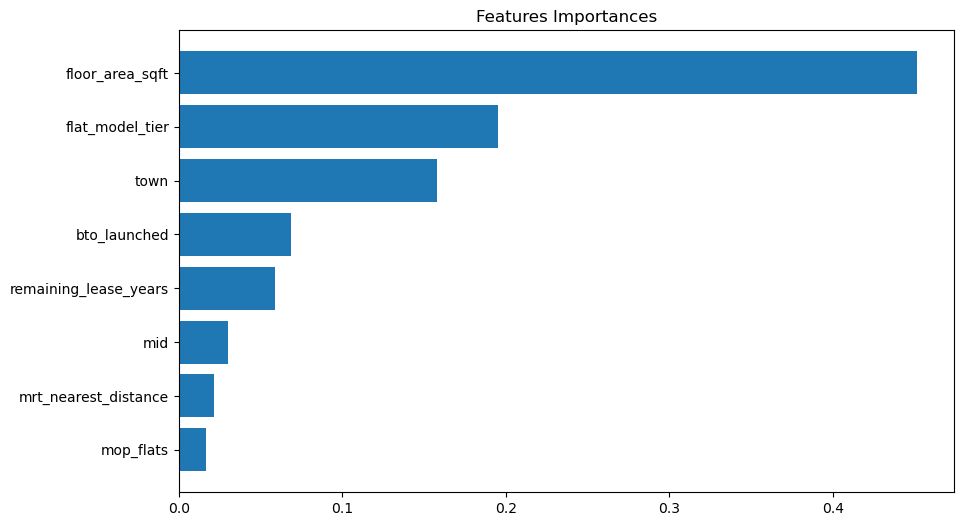

In [ ]:
## Visualise Importance

plt.figure(figsize=(10,6))
plt.barh(
    importance_df["feature"][:15],
    importance_df["importance"][:15]
)
plt.gca().invert_yaxis()
plt.title("Features Importances")
plt.show()

In [ ]:
import joblib

joblib.dump(model, "hdb_xgb_model.pkl")

['hdb_xgb_model.pkl']

In [ ]:
## To prevent feature mismatch errors

feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "model_features.pkl")

['model_features.pkl']